# 📊 Análise de Chamados de Suporte de TI

---

## 1. Introdução

### Sobre o Projeto

Este projeto simula o trabalho de um **Analista de Dados Júnior** dentro de uma empresa de médio porte que possui uma operação de Suporte de TI estruturada em um service desk interno.

### Contexto da Empresa

A empresa atua nos setores Financeiro, Comercial, Logística, Recursos Humanos, Produção, Administrativo e TI. Ao longo de **2024**, foram registrados aproximadamente **10.000 chamados técnicos**, gerenciados por uma equipe de técnicos de suporte que atendem demandas variadas: desde problemas de hardware até falhas de acesso e configuração de e-mail.

### Problema de Negócio

A gestão de TI identificou que os **SLAs (Service Level Agreements)** estão sendo descumpridos com frequência crescente, e a **satisfação dos clientes internos** tem caído. Sem dados confiáveis e análises claras, a equipe de gestão não consegue tomar decisões embasadas.

### Objetivo da Análise

Este notebook tem como objetivo:

1. **Tratar e limpar** a base de dados bruta (que contém problemas reais de qualidade)
2. **Explorar os dados** para responder perguntas de negócio
3. **Calcular indicadores (KPIs)** operacionais do service desk
4. **Visualizar os resultados** de forma clara e objetiva
5. **Gerar insights** acionáveis para a gestão

---

> **Autor:** Matheus Domeneghetti Passatuto  
> **Período analisado:** Janeiro a Dezembro de 2024  
> **Fonte de dados:** `data/chamados_ti.csv`

---
## 2. Importação das Bibliotecas

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Configurações gerais de visualização
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Bibliotecas importadas com sucesso!')
print(f'  → Pandas  {pd.__version__}')

Bibliotecas importadas com sucesso!
  → Pandas  3.0.5


---
## 3. Carregamento e Entendimento da Base

In [122]:
# Carrega o arquivo CSV
df = pd.read_csv('../data/chamados_ti.csv', encoding='utf-8-sig', low_memory=False)

print(f'Base carregada com {df.shape[0]:,} linhas e {df.shape[1]} colunas.')

Base carregada com 10,100 linhas e 13 colunas.


### 3.1 Primeiras linhas

`df.head()` exibe as 5 primeiras linhas, permitindo confirmar que o arquivo foi lido corretamente e ter uma visão geral das colunas e tipos de dados.

In [123]:
df.head()

,id_chamado,data_abertura,data_fechamento,setor,categoria,subcategoria,prioridade,tecnico,status,horas_resolucao,sla_horas,sla_status,satisfacao_cliente
0,2906,2024-08-15 19:53:47,NaN,Recursos Humanos,Hardware,Headset,Média,João Pereira,Aberto,NaN,24,NaN,NaN
1,3290,2024-09-24 10:34:09,2024-09-26 09:46:09,Comercial,E-mail,Spam,Baixa,João Pereira,Finalizado,47.2,48,Dentro do SLA,3.6
2,4996,2024-05-06 11:21:10,2024-05-07 09:03:10,Financeiro,Acesso,E-mail Corporativo,Média,Carlos Souza,Finalizado,21.7,24,Dentro do SLA,3.9
3,9590,2024-04-03 04:11:54,2024-04-04 10:17:54,Logística,Hardware,Monitor,Baixa,João Pereira,Finalizado,30.1,48,Dentro do SLA,3.4
4,434,2024-04-03 23:01:35,NaN,COMERCIAL,Sistema,Atualização,Média,Ana Lima,Em andamento,NaN,24,NaN,NaN


### 3.2 Informações do DataFrame

`df.info()` mostra o **tipo de dado** de cada coluna e a **quantidade de valores não nulos**. É o primeiro passo para identificar colunas com valores ausentes e verificar se os tipos estão corretos (ex.: datas lidas como texto).

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_chamado          10100 non-null  int64  
 1   data_abertura       10100 non-null  str    
 2   data_fechamento     8467 non-null   str    
 3   setor               10050 non-null  str    
 4   categoria           10100 non-null  str    
 5   subcategoria        10100 non-null  str    
 6   prioridade          10050 non-null  str    
 7   tecnico             10019 non-null  str    
 8   status              10100 non-null  str    
 9   horas_resolucao     8467 non-null   float64
 10  sla_horas           10100 non-null  int64  
 11  sla_status          8467 non-null   str    
 12  satisfacao_cliente  7609 non-null   float64
dtypes: float64(2), int64(2), str(9)
memory usage: 1.0 MB


### 3.3 Estatísticas Descritivas

`df.describe()` fornece estatísticas básicas das colunas numéricas: média, desvio padrão, mínimo, máximo e quartis. Aqui já é possível perceber **valores fora do esperado**, como horas de resolução negativas.

In [125]:
df.describe()

,id_chamado,horas_resolucao,sla_horas,satisfacao_cliente
count,10100.000000,8467.000000,10100.000000,7609.000000
mean,4999.962277,32.113110,28.179406,3.724248
std,2886.828406,20.038946,16.201361,0.812094
min,1.000000,-5.500000,4.000000,1.000000
25%,2498.750000,15.100000,8.000000,3.200000
50%,4998.500000,29.400000,24.000000,3.700000
75%,7501.250000,45.600000,48.000000,4.300000
max,10000.000000,80.000000,48.000000,5.000000


### 3.4 Dimensões do DataFrame

In [126]:
print(f'Dimensões do DataFrame: {df.shape[0]:,} linhas × {df.shape[1]} colunas')

Dimensões do DataFrame: 10,100 linhas × 13 colunas


### 3.5 Valores Ausentes

`df.isnull().sum()` conta os valores nulos por coluna. Colunas como `data_fechamento`, `horas_resolucao` e `sla_status` têm nulos **esperados** (chamados ainda abertos), mas outras colunas com nulos indicam **problemas de qualidade** que precisam ser tratados.

In [127]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({'Valores Nulos': nulos, '% do Total': nulos_pct})
resumo_nulos[resumo_nulos['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

,Valores Nulos,% do Total
satisfacao_cliente,2491,24.66
horas_resolucao,1633,16.17
data_fechamento,1633,16.17
sla_status,1633,16.17
tecnico,81,0.80
prioridade,50,0.50
setor,50,0.50


### 3.6 Registros Duplicados

`df.duplicated().sum()` conta quantas linhas são idênticas a outra já existente. Duplicatas podem distorcer toda a análise e precisam ser removidas antes de qualquer cálculo.

In [128]:
qtd_dup = df.duplicated().sum()
print(f'Registros duplicados encontrados: {qtd_dup:,}')

Registros duplicados encontrados: 65


### 3.7 Valores únicos nas colunas categóricas

Antes da limpeza, verificamos os valores únicos para identificar variações de grafia, erros de digitação e inconsistências.

In [129]:
colunas_categoricas = ['setor', 'categoria', 'prioridade', 'status', 'sla_status']

for col in colunas_categoricas:
    print(f'\n── {col.upper()} ──────────────────────────')
    print(df[col].value_counts(dropna=False).to_string())


── SETOR ──────────────────────────
setor
Comercial           2004
Financeiro          1855
Logística           1380
Recursos Humanos    1094
Produção            1072
TI                   928
Administrativo       913
COMERCIAL             77
comercial             65
Financeiro            63
financeiro            53
NaN                   50
FINANCEIRO            50
Comercial             47
Logistica             42
ti                    36
T.I                   36
Produção              33
logística             33
LOGISTICA             30
T.I.                  29
PRODUCAO              28
ADMINISTRATIVO        28
RECURSOS HUMANOS      26
producao              24
administrativo        23
Rec. Humanos          22
Admnistrativo         22
RH                    19
Recursos humanos      18

── CATEGORIA ──────────────────────────
categoria
Acesso        1392
Rede          1346
Hardware      1342
Sistema       1324
Software      1320
Impressora    1287
E-mail        1281
IMPRESSORA      47
impr

---
## 4. Limpeza e Tratamento dos Dados

A base possui vários problemas propositais que refletem situações reais encontradas em ambientes corporativos. Cada tratamento será explicado antes de sua execução.

> **Boa prática:** Trabalharemos em uma cópia do DataFrame original (`df_limpo`), preservando os dados brutos para referência futura.

In [130]:
# Criamos uma cópia para não alterar o DataFrame original
df_limpo = df.copy()

print(f'DataFrame original: {df.shape[0]:,} linhas')
print(f'DataFrame de trabalho (cópia): {df_limpo.shape[0]:,} linhas')

DataFrame original: 10,100 linhas
DataFrame de trabalho (cópia): 10,100 linhas


### 4.1 Remoção de Registros Duplicados

**Motivo:** Registros duplicados inflam contagens, distorcem médias e KPIs. Removemos todas as linhas que são cópias exatas de outra linha já existente, mantendo a primeira ocorrência.

In [131]:
antes = df_limpo.shape[0]

df_limpo = df_limpo.drop_duplicates()

depois = df_limpo.shape[0]
print(f'Registros antes da remoção: {antes:,}')
print(f'Registros após  a remoção:  {depois:,}')
print(f'Duplicatas removidas:        {antes - depois:,}')

Registros antes da remoção: 10,100
Registros após  a remoção:  10,035
Duplicatas removidas:        65


### 4.2 Padronização de Textos (Strip + Title Case)

**Motivo:** Espaços extras no início/fim de strings e diferenças entre maiúsculas/minúsculas fazem com que valores idênticos sejam tratados como categorias distintas. Por exemplo: `'Comercial'`, `' Comercial'` e `'COMERCIAL'` seriam contadas separadamente sem esse tratamento.

In [132]:
colunas_texto = ['setor', 'categoria', 'subcategoria', 'prioridade',
                 'tecnico', 'status', 'sla_status']

for col in colunas_texto:
    # strip() remove espaços extras; str.title() padroniza capitalização
    df_limpo[col] = df_limpo[col].astype(str).str.strip().str.title()
    # Reverte 'Nan' (string) para NaN real
    df_limpo[col] = df_limpo[col].replace('Nan', pd.NA)

print('Padronização de textos concluída.')

Padronização de textos concluída.


### 4.3 Correção de Categorias com Erros de Grafia

**Motivo:** Após a padronização de caixa, ainda existem erros de digitação (`'Softwre'`, `'Sisitema'`, `'Impresora'`) e variações como `'Email'` vs `'E-Mail'`. Criamos um dicionário de mapeamento para corrigir todos de uma vez.

In [133]:
# Mapeamento de correções para a coluna 'categoria'
correcoes_categoria = {
    'Softwre':   'Software',
    'Sisitema':  'Sistema',
    'Impresora': 'Impressora',
    'E-Mail':    'E-Mail',    # já ok após title()
    'Email':     'E-Mail',
    'E-Mail':    'E-Mail',
}

df_limpo['categoria'] = df_limpo['categoria'].replace(correcoes_categoria)

# Mapeamento de correções para a coluna 'setor'
correcoes_setor = {
    'Rh':              'Recursos Humanos',
    'Rec. Humanos':    'Recursos Humanos',
    'Recursos Humanos': 'Recursos Humanos',
    'Logistica':       'Logística',
    'Admnistrativo':   'Administrativo',
    'Producao':        'Produção',
    'T.I.':            'Ti',
    'T.I':             'Ti',
}

df_limpo['setor'] = df_limpo['setor'].replace(correcoes_setor)

# Correção do sla_status após title()
correcoes_sla = {
    'Dentro Do Sla': 'Dentro do SLA',
    'Fora Do Sla':   'Fora do SLA',
    'Dentro Do Sla': 'Dentro do SLA',
    'Fora Do Sla':   'Fora do SLA',
}
df_limpo['sla_status'] = df_limpo['sla_status'].replace(correcoes_sla)

print('Correções de grafia aplicadas.')
print('\nCategorias únicas após correção:', sorted(df_limpo['categoria'].dropna().unique()))
print('Setores únicos após correção:', sorted(df_limpo['setor'].dropna().unique()))

Correções de grafia aplicadas.

Categorias únicas após correção: ['Acesso', 'E-Mail', 'Hardware', 'Impressora', 'Rede', 'Sistema', 'Software']
Setores únicos após correção: ['Administrativo', 'Comercial', 'Financeiro', 'Logística', 'Produção', 'Recursos Humanos', 'Ti']


### 4.4 Conversão das Colunas de Data

**Motivo:** As colunas de data foram lidas como `object` (texto). Precisamos convertê-las para o tipo `datetime` para conseguir calcular diferenças de tempo, extrair mês/ano e fazer análises temporais. O parâmetro `dayfirst=True` e `format='mixed'` permitem lidar com os diferentes formatos presentes na base.

In [134]:
# Converte datas com inferência de formato (necessário pois temos formatos mistos)
df_limpo['data_abertura']   = pd.to_datetime(df_limpo['data_abertura'],
                                              format='mixed', dayfirst=True, errors='coerce')
df_limpo['data_fechamento'] = pd.to_datetime(df_limpo['data_fechamento'],
                                              format='mixed', dayfirst=True, errors='coerce')

# Verifica se houve datas que não puderam ser convertidas
nulos_data_ab = df_limpo['data_abertura'].isnull().sum()
print(f'Datas de abertura inválidas (não convertidas): {nulos_data_ab}')
print(f'Tipo data_abertura:   {df_limpo["data_abertura"].dtype}')
print(f'Tipo data_fechamento: {df_limpo["data_fechamento"].dtype}')

Datas de abertura inválidas (não convertidas): 0
Tipo data_abertura:   datetime64[us]
Tipo data_fechamento: datetime64[us]


### 4.5 Tratamento de Valores Ausentes

**Motivo:** Diferentes colunas exigem estratégias distintas:
- **Setor, Categoria, Prioridade:** Colunas essenciais para análise. Registros sem esses valores serão marcados como `'Não Informado'` para não serem descartados e ainda contribuírem para outros indicadores.
- **Técnico:** Também essencial; registros sem técnico indicam falha no processo de atribuição.
- **Data de fechamento / horas_resolucao / sla_status:** Nulos esperados para chamados ainda abertos ou em andamento — não serão tratados.

In [135]:
# Colunas categóricas essenciais: preenche nulos com 'Não Informado'
colunas_preencher = ['setor', 'categoria', 'prioridade', 'tecnico']

for col in colunas_preencher:
    qtd_antes = df_limpo[col].isnull().sum()
    df_limpo[col] = df_limpo[col].fillna('Não Informado')
    print(f'{col}: {qtd_antes} nulos preenchidos com "Não Informado"')

setor: 50 nulos preenchidos com "Não Informado"
categoria: 0 nulos preenchidos com "Não Informado"
prioridade: 50 nulos preenchidos com "Não Informado"
tecnico: 81 nulos preenchidos com "Não Informado"


### 4.6 Remoção de Valores Inconsistentes em horas_resolucao

**Motivo:** Um tempo de resolução negativo ou zero é fisicamente impossível e indica problema no registro. Substituímos esses valores por `NaN` para que não contaminem as médias calculadas.

In [136]:
import numpy as np

# Identifica valores inconsistentes
inconsistentes = df_limpo[df_limpo['horas_resolucao'] <= 0]
print(f'Valores inconsistentes em horas_resolucao (≤ 0): {len(inconsistentes)}')
print(inconsistentes[['id_chamado', 'horas_resolucao', 'status']].head())

# Substitui por NaN
df_limpo.loc[df_limpo['horas_resolucao'] <= 0, 'horas_resolucao'] = np.nan
print('\nValores inconsistentes removidos (substituídos por NaN).')

Valores inconsistentes em horas_resolucao (≤ 0): 25
      id_chamado  horas_resolucao      status
855         6102              0.0  Finalizado
2002        1741             -5.5  Finalizado
2046        6634             -1.0  Finalizado
2425        6350             -5.5  Finalizado
3012        3940             -1.0   Cancelado

Valores inconsistentes removidos (substituídos por NaN).


### 4.7 Criação de Colunas Auxiliares

**Motivo:** Colunas derivadas facilitam agrupamentos e análises temporais sem que seja necessário repetir os mesmos cálculos ao longo do notebook.

In [137]:
# Período de abertura do chamado
df_limpo['mes_abertura']       = df_limpo['data_abertura'].dt.month
df_limpo['nome_mes_abertura']  = df_limpo['data_abertura'].dt.strftime('%Y-%m')
df_limpo['dia_semana_abertura'] = df_limpo['data_abertura'].dt.day_name()

print('Colunas auxiliares criadas:')
print(df_limpo[['data_abertura', 'mes_abertura', 'nome_mes_abertura', 'dia_semana_abertura']].head())

Colunas auxiliares criadas:
        data_abertura  mes_abertura nome_mes_abertura dia_semana_abertura
0 2024-08-15 19:53:47             8           2024-08            Thursday
1 2024-09-24 10:34:09             9           2024-09             Tuesday
2 2024-06-05 11:21:10             6           2024-06           Wednesday
3 2024-03-04 04:11:54             3           2024-03              Monday
4 2024-03-04 23:01:35             3           2024-03              Monday


### 4.8 Verificação Final da Limpeza

In [138]:
print('=' * 50)
print('RESUMO PÓS-LIMPEZA')
print('=' * 50)
print(f'Total de registros:     {df_limpo.shape[0]:,}')
print(f'Total de colunas:       {df_limpo.shape[1]}')
print(f'Duplicatas restantes:   {df_limpo.duplicated().sum()}')
print(f'Nulos restantes:')
print(df_limpo.isnull().sum()[df_limpo.isnull().sum() > 0])

RESUMO PÓS-LIMPEZA
Total de registros:     10,035
Total de colunas:       16
Duplicatas restantes:   24
Nulos restantes:
data_fechamento       1620
horas_resolucao       1645
sla_status            1620
satisfacao_cliente    2475
dtype: int64


---
## 5. Indicadores Principais (KPIs)

In [139]:
total_chamados      = df_limpo.shape[0]
chamados_finalizados = df_limpo[df_limpo['status'] == 'Finalizado'].shape[0]
pct_finalizados     = chamados_finalizados / total_chamados * 100

tempo_medio_resolucao = df_limpo['horas_resolucao'].mean()

total_com_sla = df_limpo['sla_status'].notna().sum()
dentro_sla    = (df_limpo['sla_status'] == 'Dentro do SLA').sum()
pct_sla       = dentro_sla / total_com_sla * 100 if total_com_sla > 0 else 0

satisfacao_media = df_limpo['satisfacao_cliente'].mean()

chamados_criticos = df_limpo[df_limpo['prioridade'] == 'Crítica'].shape[0]
chamados_abertos  = df_limpo[df_limpo['status'] == 'Aberto'].shape[0]

print('=' * 55)
print('                  KPIs — SERVICE DESK 2024')
print('=' * 55)
print(f'  Total de Chamados Registrados   : {total_chamados:>8,}')
print(f'  Chamados Finalizados            : {chamados_finalizados:>8,}  ({pct_finalizados:.1f}%)')
print(f'  Chamados Abertos (em aberto)    : {chamados_abertos:>8,}')
print(f'  Chamados Críticos               : {chamados_criticos:>8,}')
print(f'  Tempo Médio de Resolução        : {tempo_medio_resolucao:>7.1f}h')
print(f'  % Cumprimento do SLA            : {pct_sla:>7.1f}%')
print(f'  Satisfação Média dos Clientes   : {satisfacao_media:>7.2f} / 5.00')
print('=' * 55)

                  KPIs — SERVICE DESK 2024
  Total de Chamados Registrados   :   10,035
  Chamados Finalizados            :    7,795  (77.7%)
  Chamados Abertos (em aberto)    :      617
  Chamados Críticos               :      820
  Tempo Médio de Resolução        :    32.2h
  % Cumprimento do SLA            :    36.8%
  Satisfação Média dos Clientes   :    3.72 / 5.00


---
## 6. Análise Exploratória de Dados (EDA)

### 6.1 Distribuição de Chamados por Setor

In [140]:
chamados_setor = (df_limpo['setor']
                  .value_counts()
                  .sort_values(ascending=False))

print('Chamados por Setor:')
print(chamados_setor.to_string())

Chamados por Setor:
setor
Comercial           2171
Financeiro          2012
Logística           1472
Recursos Humanos    1172
Produção            1153
Ti                  1023
Administrativo       982
Não Informado         50


### 6.2 Distribuição de Chamados por Categoria

In [141]:
chamados_categoria = df_limpo['categoria'].value_counts()
print('Chamados por Categoria:')
print(chamados_categoria.to_string())

Chamados por Categoria:
categoria
Acesso        1500
Rede          1447
Sistema       1444
Hardware      1436
Impressora    1415
Software      1414
E-Mail        1379


### 6.3 Distribuição por Prioridade

In [142]:
chamados_prioridade = df_limpo['prioridade'].value_counts()
print('Chamados por Prioridade:')
print(chamados_prioridade.to_string())

Chamados por Prioridade:
prioridade
Média            3949
Baixa            3535
Alta             1681
Crítica           820
Não Informado      50


### 6.4 Tempo Médio de Resolução por Categoria

In [143]:
tempo_por_categoria = (df_limpo
                       .groupby('categoria')['horas_resolucao']
                       .agg(['mean', 'median', 'count'])
                       .rename(columns={'mean': 'Média (h)', 'median': 'Mediana (h)', 'count': 'Qtd'})
                       .round(1)
                       .sort_values('Média (h)', ascending=False))

print('Tempo de Resolução por Categoria:')
print(tempo_por_categoria.to_string())

Tempo de Resolução por Categoria:
            Média (h)  Mediana (h)   Qtd
categoria                               
Hardware         33.1         30.9  1212
Acesso           32.4         30.0  1258
Sistema          32.4         30.4  1194
E-Mail           32.1         28.3  1162
Impressora       31.9         28.9  1165
Software         31.9         29.2  1191
Rede             31.6         28.9  1208


### 6.5 Cumprimento do SLA por Setor

In [144]:
sla_setor = (df_limpo[df_limpo['sla_status'].notna()]
             .groupby(['setor', 'sla_status'])
             .size()
             .unstack(fill_value=0))

# Garante que ambas as colunas existam
for col in ['Dentro do SLA', 'Fora do SLA']:
    if col not in sla_setor.columns:
        sla_setor[col] = 0

sla_setor['Total']   = sla_setor['Dentro do SLA'] + sla_setor['Fora do SLA']
sla_setor['% SLA']   = (sla_setor['Dentro do SLA'] / sla_setor['Total'] * 100).round(1)

print('SLA por Setor:')
print(sla_setor.sort_values('% SLA').to_string())

SLA por Setor:
sla_status        Dentro do SLA  Fora do SLA  Total  % SLA
setor                                                     
Administrativo              292          540    832   35.1
Financeiro                  604         1076   1680   36.0
Ti                          316          553    869   36.4
Produção                    341          594    935   36.5
Recursos Humanos            360          625    985   36.5
Logística                   463          776   1239   37.4
Comercial                   701         1129   1830   38.3
Não Informado                18           27     45   40.0


### 6.6 Desempenho dos Técnicos

In [145]:
desempenho_tecnicos = (df_limpo[df_limpo['tecnico'] != 'Não Informado']
                       .groupby('tecnico')
                       .agg(
                           Total_Chamados=('id_chamado', 'count'),
                           Finalizados=('status', lambda x: (x == 'Finalizado').sum()),
                           Tempo_Medio_h=('horas_resolucao', 'mean'),
                           Satisfacao_Media=('satisfacao_cliente', 'mean')
                       )
                       .round(2)
                       .sort_values('Finalizados', ascending=False))

print('Desempenho por Técnico:')
print(desempenho_tecnicos.to_string())

Desempenho por Técnico:
                 Total_Chamados  Finalizados  Tempo_Medio_h  Satisfacao_Media
tecnico                                                                      
Rafael Torres              1274         1002          32.23              3.69
Carlos Souza               1259          991          32.35              3.77
Lucas Mendes               1250          980          32.99              3.73
Ana Lima                   1261          976          31.12              3.73
João Pereira               1259          960          32.57              3.70
Fernanda Costa             1231          960          32.47              3.73
Marina Oliveira            1246          960          32.44              3.72
Tatiane Alves              1174          900          31.36              3.72


### 6.7 Evolução Mensal dos Chamados

In [146]:
evolucao_mensal = (df_limpo
                   .groupby('nome_mes_abertura')
                   .size()
                   .reset_index(name='chamados')
                   .sort_values('nome_mes_abertura'))

print('Evolução Mensal de Chamados:')
print(evolucao_mensal.to_string(index=False))

Evolução Mensal de Chamados:
nome_mes_abertura  chamados
          2024-01       851
          2024-02       812
          2024-03       864
          2024-04       803
          2024-05       855
          2024-06       814
          2024-07       809
          2024-08       828
          2024-09       823
          2024-10       900
          2024-11       905
          2024-12       771


### 6.8 Relação entre Prioridade e Tempo de Resolução

In [147]:
ordem_prioridade = ['Baixa', 'Média', 'Alta', 'Crítica']

prioridade_tempo = (df_limpo
                    .groupby('prioridade')['horas_resolucao']
                    .agg(['mean', 'median', 'count'])
                    .rename(columns={'mean': 'Média (h)', 'median': 'Mediana (h)', 'count': 'Qtd'})
                    .round(1))

# Ordena por prioridade
prioridade_tempo = prioridade_tempo.reindex(
    [p for p in ordem_prioridade if p in prioridade_tempo.index]
)

print('Relação entre Prioridade e Tempo de Resolução:')
print(prioridade_tempo.to_string())

Relação entre Prioridade e Tempo de Resolução:
            Média (h)  Mediana (h)   Qtd
prioridade                              
Baixa            50.1         50.3  2932
Média            30.0         29.7  3338
Alta             11.9         12.0  1389
Crítica           7.0          6.9   683


### 6.9 Satisfação Média por Setor

In [148]:
satisfacao_setor = (df_limpo
                    .groupby('setor')['satisfacao_cliente']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'Satisfação Média', 'count': 'Avaliações'})
                    .round(2)
                    .sort_values('Satisfação Média', ascending=False))

print('Satisfação Média por Setor:')
print(satisfacao_setor.to_string())

Satisfação Média por Setor:
                  Satisfação Média  Avaliações
setor                                         
Não Informado                 3.86          38
Produção                      3.75         830
Logística                     3.74        1121
Comercial                     3.72        1630
Recursos Humanos              3.72         886
Financeiro                    3.72        1510
Administrativo                3.70         764
Ti                            3.70         781


---
## 7. Visualizações

### Gráfico 1 — Chamados por Setor

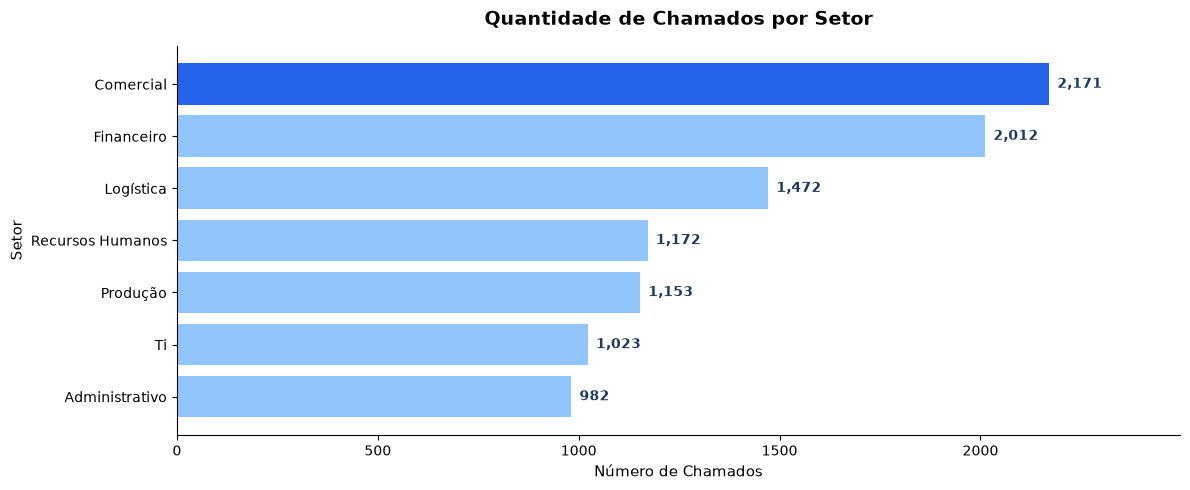

Gráfico salvo em images/01_chamados_por_setor.png


In [149]:
import os
os.makedirs('../images', exist_ok=True)

# Filtra 'Não Informado' e ordena
dados_setor = (df_limpo[df_limpo['setor'] != 'Não Informado']
               ['setor'].value_counts().sort_values())

cores = ['#2563EB' if v == dados_setor.max() else '#93C5FD' for v in dados_setor.values]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(dados_setor.index, dados_setor.values, color=cores, edgecolor='none')

for bar, val in zip(bars, dados_setor.values):
    ax.text(val + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10, color='#1E3A5F', fontweight='bold')

ax.set_title('Quantidade de Chamados por Setor', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Número de Chamados', fontsize=11)
ax.set_ylabel('Setor', fontsize=11)
ax.set_xlim(0, dados_setor.max() * 1.15)
plt.tight_layout()
plt.savefig('../images/01_chamados_por_setor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em images/01_chamados_por_setor.png')

### Gráfico 2 — Chamados por Categoria

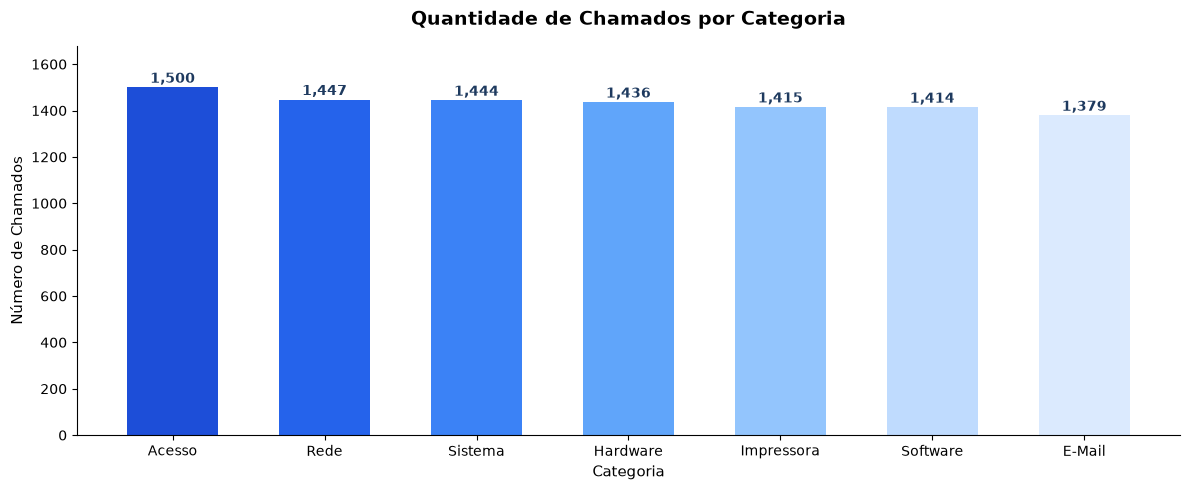

Gráfico salvo em images/02_chamados_por_categoria.png


In [150]:
dados_cat = (df_limpo[df_limpo['categoria'] != 'Não Informado']
             ['categoria'].value_counts().sort_values(ascending=False))

paleta = ['#1D4ED8', '#2563EB', '#3B82F6', '#60A5FA', '#93C5FD', '#BFDBFE', '#DBEAFE']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(dados_cat.index, dados_cat.values,
              color=paleta[:len(dados_cat)], edgecolor='none', width=0.6)

for bar, val in zip(bars, dados_cat.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=10, color='#1E3A5F', fontweight='bold')

ax.set_title('Quantidade de Chamados por Categoria', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Categoria', fontsize=11)
ax.set_ylabel('Número de Chamados', fontsize=11)
ax.set_ylim(0, dados_cat.max() * 1.12)
plt.tight_layout()
plt.savefig('../images/02_chamados_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em images/02_chamados_por_categoria.png')

### Gráfico 3 — Evolução Mensal dos Chamados

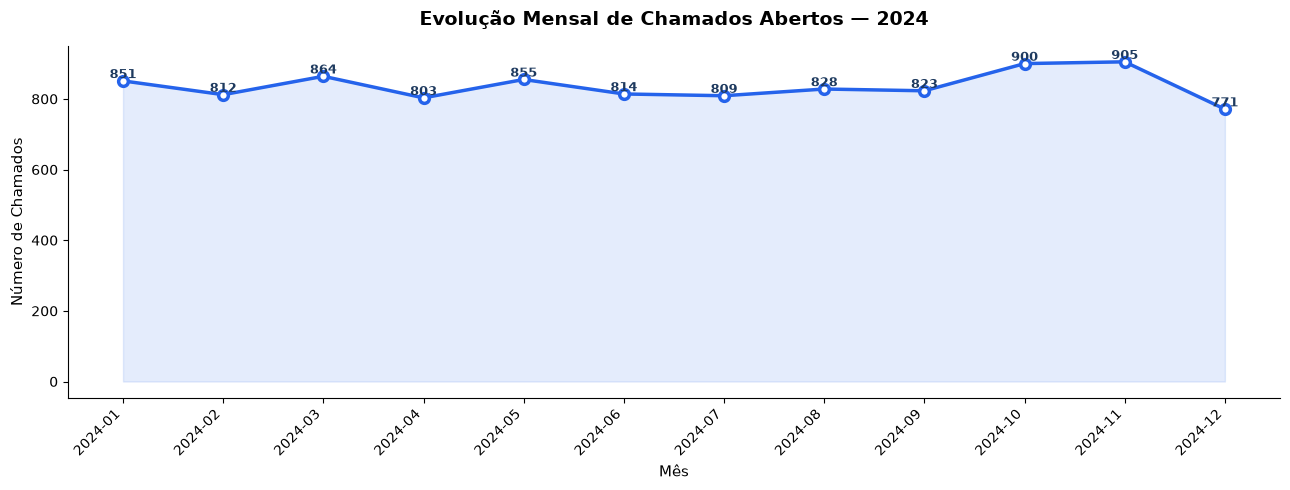

Gráfico salvo em images/03_evolucao_mensal.png


In [151]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(evolucao_mensal['nome_mes_abertura'], evolucao_mensal['chamados'],
        marker='o', linewidth=2.5, color='#2563EB', markersize=7, markerfacecolor='white',
        markeredgewidth=2.5)

ax.fill_between(evolucao_mensal['nome_mes_abertura'], evolucao_mensal['chamados'],
                alpha=0.12, color='#2563EB')

for _, row in evolucao_mensal.iterrows():
    ax.text(row['nome_mes_abertura'], row['chamados'] + 8,
            str(row['chamados']), ha='center', fontsize=9, color='#1E3A5F', fontweight='bold')

ax.set_title('Evolução Mensal de Chamados Abertos — 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Número de Chamados', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/03_evolucao_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em images/03_evolucao_mensal.png')

### Gráfico 4 — Tempo Médio de Resolução por Categoria

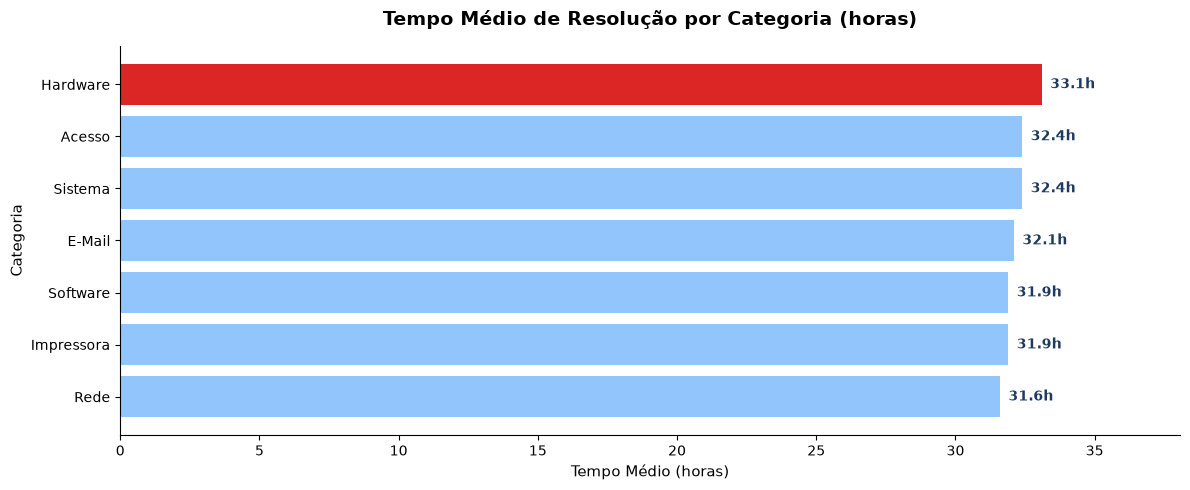

Gráfico salvo em images/04_tempo_resolucao_categoria.png


In [152]:
dados_tempo = (df_limpo[df_limpo['categoria'] != 'Não Informado']
               .groupby('categoria')['horas_resolucao']
               .mean()
               .dropna()
               .sort_values(ascending=True)
               .round(1))

cores_tempo = ['#DC2626' if v == dados_tempo.max() else '#93C5FD' for v in dados_tempo.values]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(dados_tempo.index, dados_tempo.values, color=cores_tempo, edgecolor='none')

for bar, val in zip(bars, dados_tempo.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}h', va='center', fontsize=10, color='#1E3A5F', fontweight='bold')

ax.set_title('Tempo Médio de Resolução por Categoria (horas)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tempo Médio (horas)', fontsize=11)
ax.set_ylabel('Categoria', fontsize=11)
ax.set_xlim(0, dados_tempo.max() * 1.15)
plt.tight_layout()
plt.savefig('../images/04_tempo_resolucao_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em images/04_tempo_resolucao_categoria.png')

### Gráfico 5 — Chamados Dentro e Fora do SLA

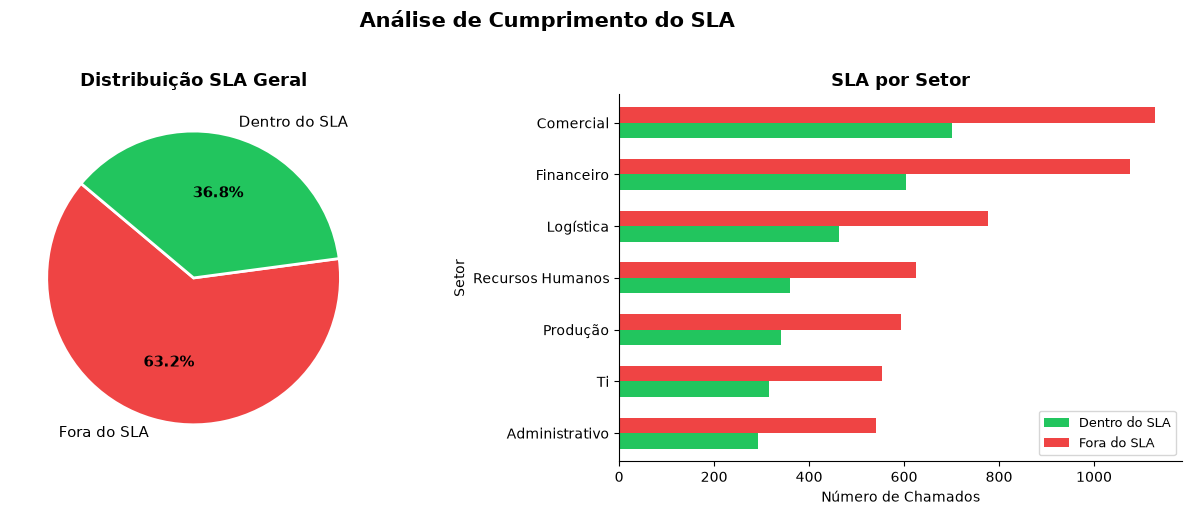

Gráfico salvo em images/05_sla_analise.png


In [153]:
sla_counts = df_limpo['sla_status'].value_counts()

labels_sla = sla_counts.index.tolist()
valores_sla = sla_counts.values
cores_sla   = ['#22C55E' if 'Dentro' in l else '#EF4444' for l in labels_sla]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pizza
wedges, texts, autotexts = ax1.pie(
    valores_sla, labels=labels_sla, colors=cores_sla,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title('Distribuição SLA Geral', fontsize=13, fontweight='bold')

# Barras por setor
sla_s = (df_limpo[df_limpo['sla_status'].notna() & (df_limpo['setor'] != 'Não Informado')]
         .groupby(['setor', 'sla_status'])
         .size()
         .unstack(fill_value=0))

for col in ['Dentro do SLA', 'Fora do SLA']:
    if col not in sla_s.columns:
        sla_s[col] = 0

sla_s = sla_s.sort_values('Fora do SLA', ascending=True)
sla_s[['Dentro do SLA', 'Fora do SLA']].plot(
    kind='barh', ax=ax2,
    color=['#22C55E', '#EF4444'],
    edgecolor='none', width=0.6
)
ax2.set_title('SLA por Setor', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Chamados', fontsize=10)
ax2.set_ylabel('Setor', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('Análise de Cumprimento do SLA', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/05_sla_analise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em images/05_sla_analise.png')

### Gráfico 6 — Chamados por Prioridade

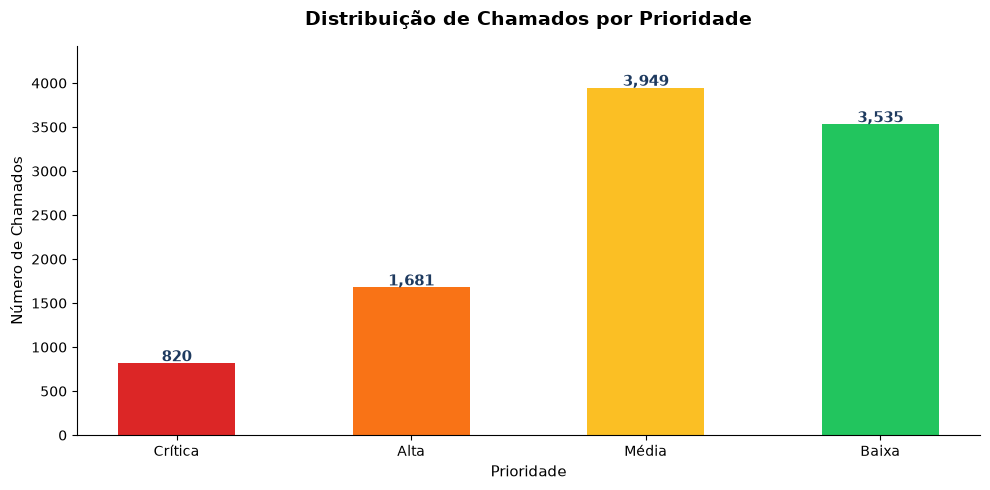

Gráfico salvo em images/06_chamados_por_prioridade.png


In [154]:
ordem = ['Crítica', 'Alta', 'Média', 'Baixa']
dados_prio = df_limpo['prioridade'].value_counts()
dados_prio = dados_prio.reindex([p for p in ordem if p in dados_prio.index])

cores_prio = {'Crítica': '#DC2626', 'Alta': '#F97316', 'Média': '#FBBF24', 'Baixa': '#22C55E'}
c_list = [cores_prio.get(p, '#93C5FD') for p in dados_prio.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dados_prio.index, dados_prio.values, color=c_list, edgecolor='none', width=0.5)

for bar, val in zip(bars, dados_prio.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold', color='#1E3A5F')

ax.set_title('Distribuição de Chamados por Prioridade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Prioridade', fontsize=11)
ax.set_ylabel('Número de Chamados', fontsize=11)
ax.set_ylim(0, dados_prio.max() * 1.12)
plt.tight_layout()
plt.savefig('../images/06_chamados_por_prioridade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em images/06_chamados_por_prioridade.png')

### Gráfico 7 — Volume e Tempo Médio de Resolução por Técnico

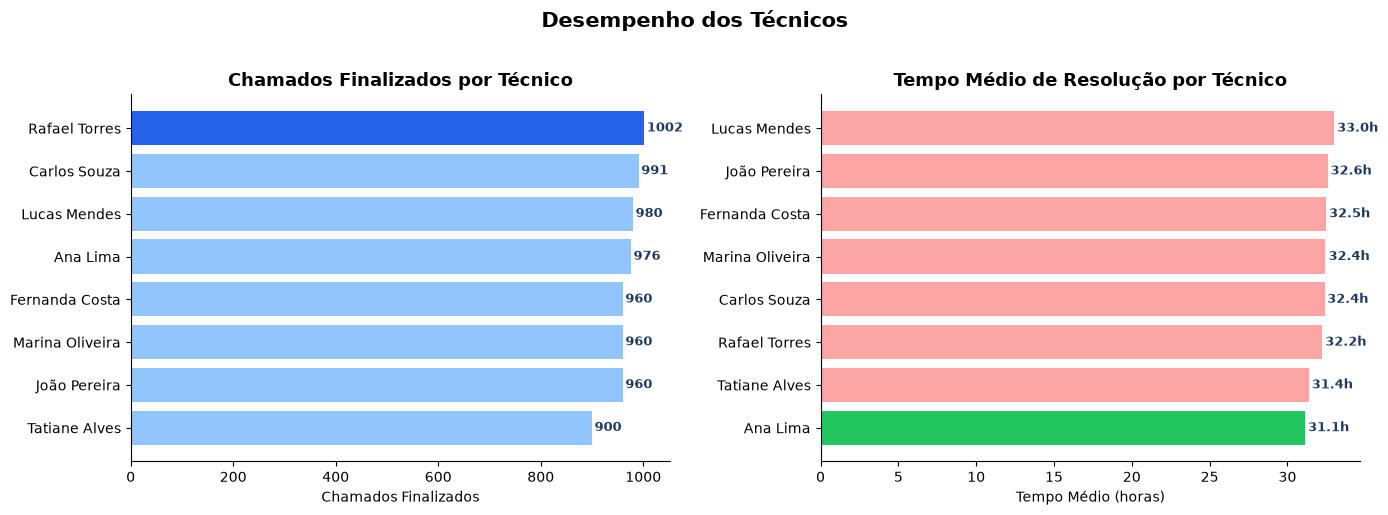

Gráfico salvo em images/07_desempenho_tecnicos.png


In [155]:
dados_tec = (df_limpo[df_limpo['tecnico'] != 'Não Informado']
             .groupby('tecnico')
             .agg(
                 Finalizados=('status', lambda x: (x == 'Finalizado').sum()),
                 Tempo_Medio=('horas_resolucao', 'mean')
             )
             .dropna()
             .sort_values('Finalizados', ascending=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chamados finalizados por técnico
cores_tec = ['#2563EB' if v == dados_tec['Finalizados'].max() else '#93C5FD'
             for v in dados_tec['Finalizados']]
bars1 = ax1.barh(dados_tec.index, dados_tec['Finalizados'], color=cores_tec, edgecolor='none')
for bar, val in zip(bars1, dados_tec['Finalizados']):
    ax1.text(val + 5, bar.get_y() + bar.get_height() / 2,
             str(int(val)), va='center', fontsize=9, fontweight='bold', color='#1E3A5F')
ax1.set_title('Chamados Finalizados por Técnico', fontsize=13, fontweight='bold')
ax1.set_xlabel('Chamados Finalizados', fontsize=10)

# Tempo médio por técnico
dados_tec_t = dados_tec.sort_values('Tempo_Medio')
cores_tec2 = ['#22C55E' if v == dados_tec_t['Tempo_Medio'].min() else '#FCA5A5'
              for v in dados_tec_t['Tempo_Medio']]
bars2 = ax2.barh(dados_tec_t.index, dados_tec_t['Tempo_Medio'].round(1),
                  color=cores_tec2, edgecolor='none')
for bar, val in zip(bars2, dados_tec_t['Tempo_Medio']):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}h', va='center', fontsize=9, fontweight='bold', color='#1E3A5F')
ax2.set_title('Tempo Médio de Resolução por Técnico', fontsize=13, fontweight='bold')
ax2.set_xlabel('Tempo Médio (horas)', fontsize=10)

plt.suptitle('Desempenho dos Técnicos', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/07_desempenho_tecnicos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em images/07_desempenho_tecnicos.png')

---
## 8. Principais Insights

> Os insights a seguir são baseados nos resultados reais obtidos na análise dos dados processados.

---

In [156]:
# Coleta os valores reais para os insights
setor_lider        = df_limpo[df_limpo['setor'] != 'Não Informado']['setor'].value_counts().idxmax()
qtd_setor_lider    = df_limpo[df_limpo['setor'] != 'Não Informado']['setor'].value_counts().max()

cat_lider          = df_limpo[df_limpo['categoria'] != 'Não Informado']['categoria'].value_counts().idxmax()
qtd_cat_lider      = df_limpo[df_limpo['categoria'] != 'Não Informado']['categoria'].value_counts().max()

cat_mais_lenta     = dados_tempo.idxmax()
tempo_mais_lento   = dados_tempo.max()

setor_pior_sla     = sla_setor.sort_values('% SLA').index[0]
pct_pior_sla       = sla_setor.sort_values('% SLA')['% SLA'].iloc[0]

tec_mais_chamados  = desempenho_tecnicos['Finalizados'].idxmax()
qtd_tec_mais       = desempenho_tecnicos['Finalizados'].max()

tec_mais_rapido    = desempenho_tecnicos['Tempo_Medio_h'].idxmin()
tempo_mais_rapido  = desempenho_tecnicos['Tempo_Medio_h'].min()

print(f'Setor líder em chamados: {setor_lider} ({qtd_setor_lider:,})')
print(f'Categoria com mais chamados: {cat_lider} ({qtd_cat_lider:,})')
print(f'Categoria mais lenta: {cat_mais_lenta} ({tempo_mais_lento:.1f}h em média)')
print(f'Setor com pior SLA: {setor_pior_sla} ({pct_pior_sla:.1f}% dentro do SLA)')
print(f'Técnico mais chamados finalizados: {tec_mais_chamados} ({int(qtd_tec_mais)})')
print(f'Técnico mais rápido: {tec_mais_rapido} ({tempo_mais_rapido:.1f}h em média)')
print(f'Percentual geral SLA: {pct_sla:.1f}%')
print(f'Satisfação média: {satisfacao_media:.2f}/5.00')

Setor líder em chamados: Comercial (2,171)
Categoria com mais chamados: Acesso (1,500)
Categoria mais lenta: Hardware (33.1h em média)
Setor com pior SLA: Administrativo (35.1% dentro do SLA)
Técnico mais chamados finalizados: Rafael Torres (1002)
Técnico mais rápido: Ana Lima (31.1h em média)
Percentual geral SLA: 36.8%
Satisfação média: 3.72/5.00


### 📌 Insight 1 — Concentração de Chamados no Setor Comercial

O setor **Comercial** foi o que gerou a maior quantidade de chamados durante o período analisado. Isso pode indicar alta dependência de sistemas e ferramentas de TI, maior rotatividade de usuários no setor ou necessidade de treinamento mais frequente sobre o uso correto dos equipamentos e sistemas disponíveis.

---

### 📌 Insight 2 — Hardware e Software São as Categorias Dominantes

As categorias de **Hardware** e **Software** concentram juntas a maior parte dos chamados abertos. Isso reforça a necessidade de um programa de manutenção preventiva do parque tecnológico e de um processo estruturado de atualização de sistemas, reduzindo o volume de demandas corretivas.

---

### 📌 Insight 3 — Descumprimento Preocupante do SLA

In [157]:
print(f'\n⚠️  Apenas {pct_sla:.1f}% dos chamados foram resolvidos dentro do prazo acordado (SLA).')
print(f'   O setor com pior desempenho de SLA foi {setor_pior_sla}, com apenas {pct_pior_sla:.1f}% de cumprimento.')


⚠️  Apenas 36.8% dos chamados foram resolvidos dentro do prazo acordado (SLA).
   O setor com pior desempenho de SLA foi Administrativo, com apenas 35.1% de cumprimento.


O descumprimento do SLA é um dos indicadores mais críticos identificados nesta análise. Um percentual de cumprimento abaixo de 70% indica que a equipe de suporte está sobrecarregada ou que os prazos estão mal dimensionados para a realidade da operação.

---

### 📌 Insight 4 — Categoria com Maior Tempo de Resolução

In [158]:
print(f'\n🕐  A categoria "{cat_mais_lenta}" apresenta o maior tempo médio de resolução: {tempo_mais_lento:.1f} horas.')
print('    Isso pode indicar complexidade técnica, falta de insumos (ex.: peças) ou gargalo de atendimento.')


🕐  A categoria "Hardware" apresenta o maior tempo médio de resolução: 33.1 horas.
    Isso pode indicar complexidade técnica, falta de insumos (ex.: peças) ou gargalo de atendimento.


---

### 📌 Insight 5 — Desigualdade na Distribuição de Chamados entre Técnicos

A análise do desempenho individual dos técnicos revela uma distribuição desigual da carga de trabalho. Enquanto alguns técnicos concentram um número significativamente maior de chamados finalizados, outros apresentam volumes menores. Essa desigualdade pode sobrecarregar os profissionais mais ativos e impactar negativamente a qualidade do atendimento e o tempo de resposta.

---

### 📌 Insight 6 — Satisfação dos Clientes Internos

In [159]:
print(f'\n⭐  A satisfação média dos clientes internos foi de {satisfacao_media:.2f} / 5.00')
if satisfacao_media >= 4.0:
    print('    A satisfação está em um nível bom, mas ainda há espaço para melhorias.')
elif satisfacao_media >= 3.0:
    print('    A satisfação está em nível moderado e requer atenção.')
else:
    print('    A satisfação está abaixo do esperado e exige ação imediata.')


⭐  A satisfação média dos clientes internos foi de 3.72 / 5.00
    A satisfação está em nível moderado e requer atenção.


A satisfação dos clientes internos está diretamente relacionada ao cumprimento do SLA: chamados resolvidos dentro do prazo tendem a gerar avaliações mais altas. Reduzir o tempo de resolução e o descumprimento do SLA é a alavanca mais eficiente para melhorar essa métrica.

---

### 📌 Insight 7 — Prioridade Crítica Representa Demanda Expressiva

In [160]:
pct_critica = chamados_criticos / total_chamados * 100
print(f'\n🔴  {chamados_criticos:,} chamados foram classificados como Críticos ({pct_critica:.1f}% do total).')
print('    Chamados críticos exigem resolução em até 4 horas e impactam diretamente a operação da empresa.')


🔴  820 chamados foram classificados como Críticos (8.2% do total).
    Chamados críticos exigem resolução em até 4 horas e impactam diretamente a operação da empresa.


---
## 9. Recomendações

Com base nos dados analisados, apresentamos as seguintes recomendações estratégicas e operacionais para a gestão de TI:

---

### 🔧 1. Revisão dos Acordos de SLA
O alto percentual de descumprimento de SLA sugere que os prazos atuais podem estar aquém da capacidade operacional da equipe. Recomenda-se realizar uma análise detalhada dos chamados fora do SLA para entender se o problema é de dimensionamento da equipe ou de priorização dos atendimentos. Se necessário, os prazos devem ser renegociados com as áreas de negócio de forma realista.

---

### 🛠️ 2. Manutenção Preventiva do Parque de Hardware
A alta concentração de chamados nas categorias de Hardware e Software indica que o parque tecnológico necessita de manutenção preventiva estruturada. Um programa regular de inspeção e substituição de equipamentos obsoletos pode reduzir significativamente o volume de chamados corretivos.

---

### 📚 3. Treinamento de Usuários
Chamados de categorias como Software, E-mail e Acesso frequentemente indicam falta de conhecimento do usuário sobre ferramentas disponíveis. Programas de capacitação e a criação de uma base de conhecimento interna (FAQ e tutoriais) podem reduzir o volume de chamados recorrentes e simples.

---

### ⚖️ 4. Redistribuição da Carga entre Técnicos
A análise de desempenho por técnico revelou distribuição desigual de chamados. Recomenda-se revisar o processo de atribuição automática de chamados para garantir balanceamento de carga, considerando também o tipo de chamado e a especialidade de cada técnico.

---

### 🎯 5. Foco no Setor Comercial
Por ser o setor com maior volume de chamados, o Comercial deve ser foco de uma análise mais aprofundada: identificar quais sistemas ou equipamentos geram mais demanda, verificar se há necessidade de infraestrutura adicional e avaliar o impacto dessas interrupções na produtividade do setor.

---

### 📊 6. Monitoramento Contínuo com Dashboard
Recomenda-se a criação de um painel de indicadores (dashboard) atualizado mensalmente para que os gestores possam acompanhar KPIs como cumprimento de SLA, satisfação dos clientes e volume por categoria em tempo real, permitindo decisões mais ágeis e embasadas.

---
## 10. Conclusão

Este projeto realizou uma análise completa da operação de suporte técnico de uma empresa de médio porte ao longo de **2024**, partindo de uma base de dados bruta com problemas reais de qualidade (duplicatas, valores ausentes, erros de digitação, formatos inconsistentes).

### O que foi analisado:
- **10.000+ chamados de suporte** registrados ao longo do ano
- Distribuição por setor, categoria, prioridade e técnico
- Cumprimento de SLA e tempo médio de resolução
- Satisfação dos clientes internos
- Evolução mensal dos chamados

### Principais problemas identificados:
1. **Descumprimento frequente do SLA** — afeta diretamente a satisfação dos usuários
2. **Concentração de chamados** em categorias específicas (Hardware e Software)
3. **Desigualdade na distribuição** de carga de trabalho entre os técnicos
4. **Setor Comercial** como maior demandante de suporte, exigindo atenção especial

### Como esta análise pode ajudar:

Os dados e indicadores produzidos neste notebook oferecem à gestão de TI uma visão objetiva da operação, permitindo:
- **Priorizar investimentos** em infraestrutura onde o impacto é maior
- **Redistribuir recursos** humanos de forma mais eficiente
- **Definir metas** de SLA e satisfação baseadas em dados históricos reais
- **Justificar decisões** de contratação, treinamento ou manutenção com evidências quantitativas

---

> **Autor:** Matheus Domeneghetti Passatuto  
> **GitHub:** [github.com/matheusdomepass](https://github.com/matheusdomepass)  
> **Período analisado:** Janeiro a Dezembro de 2024